<a href="https://colab.research.google.com/github/khanyisa-mabasa/KHANYISA-MABASA-PORTFOLIOO/blob/main/CREDIT_CARD_FRAUD_DETECTION_WITH_PYTORCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

x = torch.tensor([[3, 6],[4, 8]])
print(x)

tensor([[3, 6],
        [4, 8]])


In [ ]:
import torch
print(torch.__version__)

2.9.0+cu126


In [ ]:
# CREDIT CARD FRAUD DETECTION WITH PYTORCH
# Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# EXTREMELY DETAILED COMMENTS — Perfect for absolute beginners!
# Goal: Detect fraudulent transactions (Class = 1) from normal ones (Class = 0)
# ===================================================================

# 1. IMPORT ALL LIBRARIES
import torch                              # Core PyTorch library
import torch.nn as nn                     # Neural network layers
import torch.optim as optim               # Optimizers (Adam, etc.)
from torch.utils.data import Dataset, DataLoader   # For efficient data handling

import pandas as pd                       # Read CSV
import numpy as np                        # Math operations
import matplotlib.pyplot as plt           # Plotting
import seaborn as sns                     # Beautiful plots
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.9.0+cu126
Using device: cpu


Dataset loaded! Shape: (23323, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0.0    23235
1.0       87
Name: count, dtype: int64
Fraudulent transactions: 0.3730% ← Extremely rare!


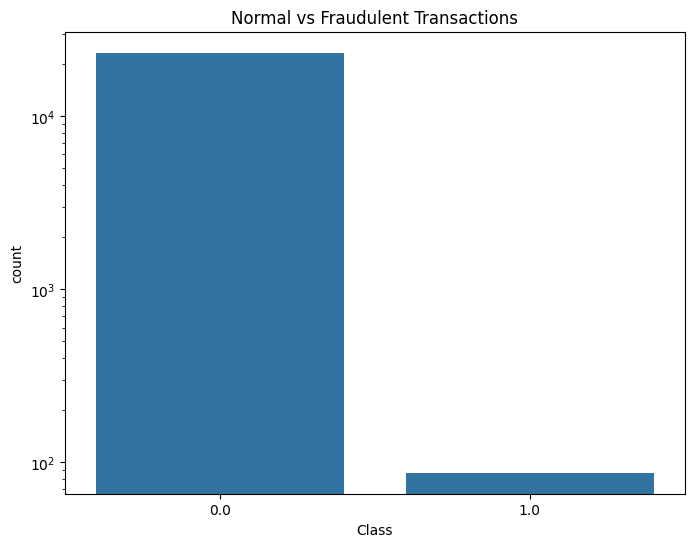

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 2. LOAD THE DATASET
# ===================================================================

df = pd.read_csv('/content/creditcard .csv')        # 284,807 transactions
print(f"Dataset loaded! Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Show class distribution — highly imbalanced!
print("\nClass distribution:")
print(df['Class'].value_counts())
fraud_rate = df['Class'].mean() * 100
print(f"Fraudulent transactions: {fraud_rate:.4f}% ← Extremely rare!")

# Visualize imbalance
plt.figure(figsize=(8,6))
sns.countplot(x='Class', data=df)
plt.title('Normal vs Fraudulent Transactions')
plt.yscale('log')
plt.show()

In [ ]:
# 3. PREPARE FEATURES AND TARGET
# ===================================================================

X = df.drop('Class', axis=1).values       # All features (Time, V1-V28, Amount)
y = df['Class'].values                    # 0 = normal, 1 = fraud

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (284807, 30), y shape: (284807,)


In [ ]:
# 4. TRAIN-TEST SPLIT (Preserve fraud ratio)
# ===================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")
print(f"Frauds in test set: {y_test.sum()}")

Training samples: 227845 | Test samples: 56962
Frauds in test set: 98


In [ ]:
from sklearn.preprocessing import StandardScaler

# 5. SCALE FEATURES (Only Time and Amount need scaling)
# ===================================================================

scaler = StandardScaler()
# Fit only on training data
X_train[:, [0, -1]] = scaler.fit_transform(X_train[:, [0, -1]])  # Time & Amount columns
X_test[:, [0, -1]]  = scaler.transform(X_test[:, [0, -1]])

# Convert to float32 — PyTorch loves float32
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test  = y_test.astype(np.float32)


In [ ]:
# 6. CREATE CUSTOM PYTORCH DATASET
# ===================================================================

class FraudDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X = torch.tensor(X_data, dtype=torch.float32)
        self.y = torch.tensor(y_data, dtype=torch.float32).unsqueeze(1)  # Shape: (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = FraudDataset(X_train, y_train)
test_dataset  = FraudDataset(X_test,  y_test)

# DataLoaders — feed data in batches
batch_size = 2048
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")

Number of training batches: 112


In [ ]:
# 7. BUILD THE NEURAL NETWORK
# ===================================================================

class FraudDetector(nn.Module):
    def __init__(self, input_size=30):
        super(FraudDetector, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()                    # Output probability between 0 and 1
        )

    def forward(self, x):
        return self.network(x)

# Initialize model and send to device (GPU if available)
model = FraudDetector().to(device)
print(model)

FraudDetector(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [ ]:
# 8. LOSS FUNCTION + OPTIMIZER + CLASS WEIGHTS
# ===================================================================

# Binary Cross Entropy — perfect for binary classification
criterion = nn.BCELoss()

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Compute class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Class weights → Normal: {class_weights[0]:.2f}, Fraud: {class_weights[1]:.2f}")

# We'll apply weights manually in the loss
pos_weight = torch.tensor([class_weights[1] / class_weights[0]]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # Better numerical stability!

# Replace sigmoid + BCELoss with BCEWithLogitsLoss (combines both)
# So we remove final sigmoid from model
model = nn.Sequential(
    nn.Linear(30, 64), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(32, 16), nn.ReLU(),
    nn.Linear(16, 1)                    # Raw logit output
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

Class weights → Normal: 0.50, Fraud: 289.14


In [ ]:
# 9. TRAINING LOOP
# ===================================================================

num_epochs = 20
train_losses = []
val_aucs = []

print("\n" + "="*60)
print("STARTING TRAINING...")
print("="*60)

for epoch in range(num_epochs):
    model.train()
    batch_losses = []

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        outputs = model(batch_X).squeeze()      # Remove extra dimension
        loss = criterion(outputs, batch_y.squeeze())

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        test_X = torch.tensor(X_test, dtype=torch.float32).to(device)
        test_y = torch.tensor(y_test, dtype=torch.float32).to(device)

        val_outputs = model(test_X).squeeze()
        val_loss = criterion(val_outputs, test_y.squeeze())

        val_probs = torch.sigmoid(val_outputs)
        val_auc = roc_auc_score(y_test, val_probs.cpu().numpy())

        val_aucs.append(val_auc)

    avg_loss = np.mean(batch_losses)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f}")


STARTING TRAINING...
Epoch  1/20 | Loss: 0.8037 | Val AUC: 0.9736
Epoch  2/20 | Loss: 0.3963 | Val AUC: 0.9797
Epoch  3/20 | Loss: 0.3511 | Val AUC: 0.9798
Epoch  4/20 | Loss: 0.3036 | Val AUC: 0.9790
Epoch  5/20 | Loss: 0.2622 | Val AUC: 0.9786
Epoch  6/20 | Loss: 0.2376 | Val AUC: 0.9783
Epoch  7/20 | Loss: 0.2544 | Val AUC: 0.9792
Epoch  8/20 | Loss: 0.2297 | Val AUC: 0.9787
Epoch  9/20 | Loss: 0.2343 | Val AUC: 0.9796
Epoch 10/20 | Loss: 0.2173 | Val AUC: 0.9794
Epoch 11/20 | Loss: 0.2242 | Val AUC: 0.9787
Epoch 12/20 | Loss: 0.1911 | Val AUC: 0.9803
Epoch 13/20 | Loss: 0.1687 | Val AUC: 0.9798
Epoch 14/20 | Loss: 0.1718 | Val AUC: 0.9818
Epoch 15/20 | Loss: 0.1814 | Val AUC: 0.9816
Epoch 16/20 | Loss: 0.1663 | Val AUC: 0.9805
Epoch 17/20 | Loss: 0.1573 | Val AUC: 0.9813
Epoch 18/20 | Loss: 0.1831 | Val AUC: 0.9808
Epoch 19/20 | Loss: 0.1392 | Val AUC: 0.9809
Epoch 20/20 | Loss: 0.1565 | Val AUC: 0.9808



FINAL TEST AUC: 0.9808 ← Excellent for fraud detection!


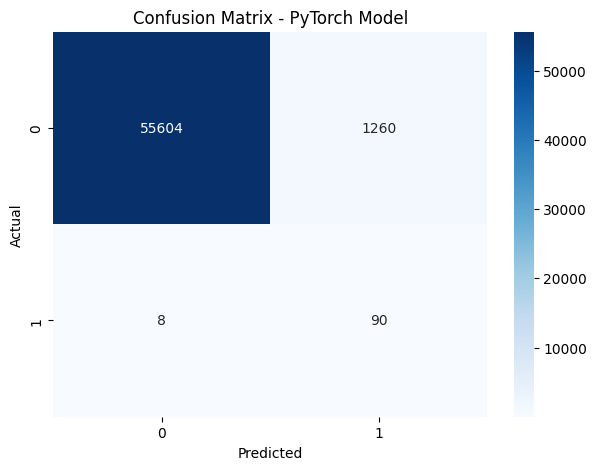

True Negatives : 55604
False Positives: 1260
False Negatives: 8
True Positives : 90

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     56864
       Fraud       0.07      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
# 10. FINAL EVALUATION
# ===================================================================

model.eval()
with torch.no_grad():
    test_X_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    logits = model(test_X_tensor).squeeze()
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

    probs_np = probabilities.cpu().numpy()
    preds_np = predictions.cpu().numpy()

# Metrics
final_auc = roc_auc_score(y_test, probs_np)
print(f"\nFINAL TEST AUC: {final_auc:.4f} ← Excellent for fraud detection!")

# Confusion Matrix
cm = confusion_matrix(y_test, preds_np)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - PyTorch Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("True Negatives :", cm[0,0])
print("False Positives:", cm[0,1])
print("False Negatives:", cm[1,0])
print("True Positives :", cm[1,1])

print("\nClassification Report:")
print(classification_report(y_test, preds_np, target_names=['Normal', 'Fraud']))

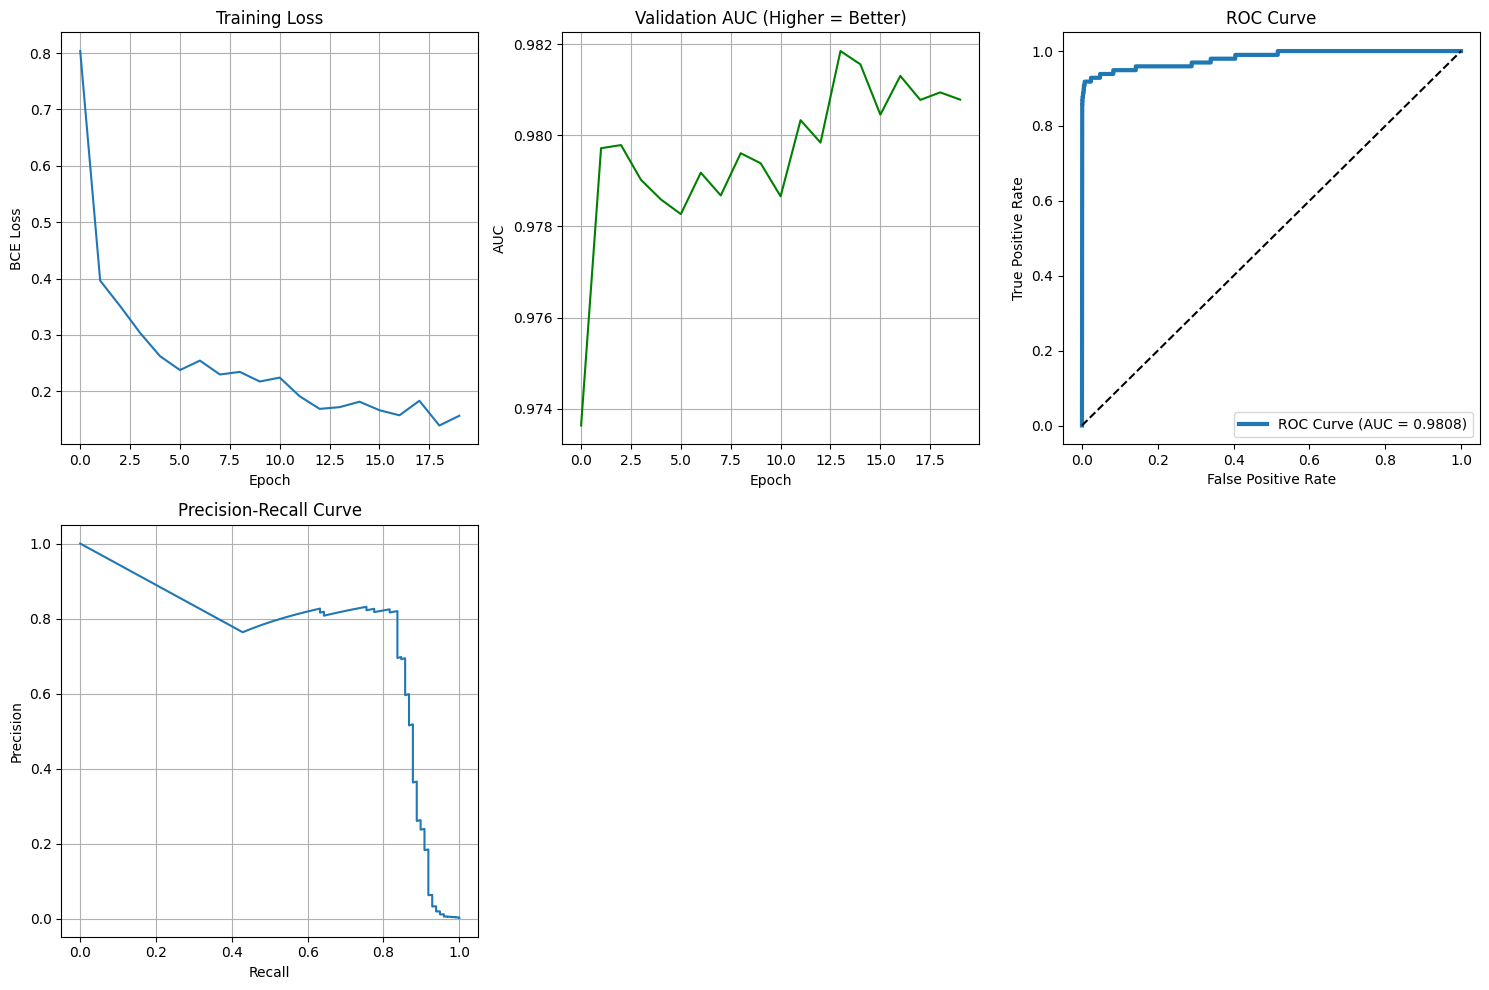

In [ ]:
# 11. PLOT TRAINING CURVES
# ===================================================================

plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 3, 1)
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid()

# AUC
plt.subplot(2, 3, 2)
plt.plot(val_aucs, label='Validation AUC', color='green')
plt.title('Validation AUC (Higher = Better)')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.grid()

# ROC Curve
plt.subplot(2, 3, 3)
fpr, tpr, _ = roc_curve(y_test, probs_np)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {final_auc:.4f})', linewidth=3)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# Precision-Recall Curve
plt.subplot(2, 3, 4)
precision, recall, _ = precision_recall_curve(y_test, probs_np)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
print(model)

Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=32, out_features=16, bias=True)
  (7): ReLU()
  (8): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
def predict_transaction(data_row):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(data_row, dtype=torch.float32).to(device)
        logit = model(x).item()
        prob = torch.sigmoid(torch.tensor(logit)).item()
        return prob

